In [1]:
print("CEMVI notebook ready")

CEMVI notebook ready


In [2]:
from pathlib import Path
import csv

csv_path = Path("data/cooling_demand.csv")
if not csv_path.exists():
    csv_path = Path("../data/cooling_demand.csv")

with csv_path.open(newline="", encoding="utf-8-sig") as file:
    rows = list(csv.DictReader(file))

hours = [row["hour"] for row in rows]
heat_kw = [int(row["total_kw"]) for row in rows]

print("Hours loaded:", len(rows))
print("Heat at 00:00:", heat_kw[0], "kW")
print("Heat at 12:00:", heat_kw[12], "kW")

Hours loaded: 24
Heat at 00:00: 15 kW
Heat at 12:00: 33 kW


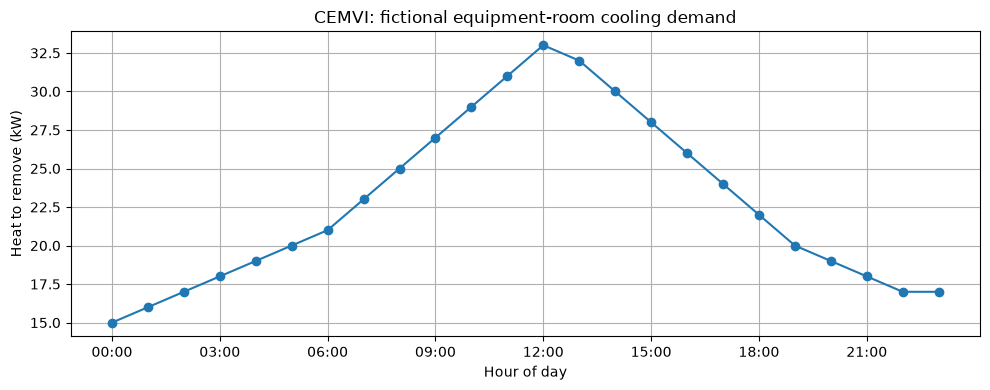

Graph saved: 01_cooling_demand.png


In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(hours)), heat_kw, marker="o")

ax.set_xticks(range(0, 24, 3), hours[::3])
ax.set_xlabel("Hour of day")
ax.set_ylabel("Heat to remove (kW)")
ax.set_title("CEMVI: fictional equipment-room cooling demand")
ax.grid(True)
fig.tight_layout()

graph_path = csv_path.resolve().parent.parent / "figures" / "01_cooling_demand.png"
graph_path.parent.mkdir(exist_ok=True)
fig.savefig(graph_path, dpi=150)

plt.show()
print("Graph saved:", graph_path.name)

00:00: 2 + 13 + 0 = 15 kW
12:00: 26 + 1 + 6 = 33 kW
23:00: 4 + 13 + 0 = 17 kW

In [4]:
mistakes = []

for row in rows:
    calculated = (
        int(row["equipment_a_kw"])
        + int(row["equipment_b_kw"])
        + int(row["solar_kw"])
    )
    if calculated != int(row["total_kw"]):
        mistakes.append(row["hour"])

peak = max(heat_kw)

print("Hours checked:", len(rows))
print("Hours with incorrect totals:", mistakes)
print("Highest heat load:", peak, "kW at", hours[heat_kw.index(peak)])
print("Daily heat to remove:", sum(heat_kw), "kWh thermal")

Hours checked: 24
Hours with incorrect totals: []
Highest heat load: 33 kW at 12:00
Daily heat to remove: 547 kWh thermal


From the result above, it is important to note that the most cooling occur at 12.00, when its heat load reaches 33kW while its lowest cooling occurs at 0.00 when its heat load is 15kW. If each row represents the average load during one hour, the system must remove 547kWh of heat over the day. It is important to note that this is heat removed, not electricity consumed by the chiller.

# CEMVI fictional cooling demand.

In [5]:
peak_kw = max(heat_kw)
water_cp = 4.19        # kJ/(kg K), approximate public-source value
water_in_c = 7         # invented
water_out_c = 12       # invented

flow_kg_s = peak_kw / (water_cp * (water_out_c - water_in_c))
print(f"Peak chilled-water flow: {flow_kg_s:.2f} kg/s")

Peak chilled-water flow: 1.58 kg/s


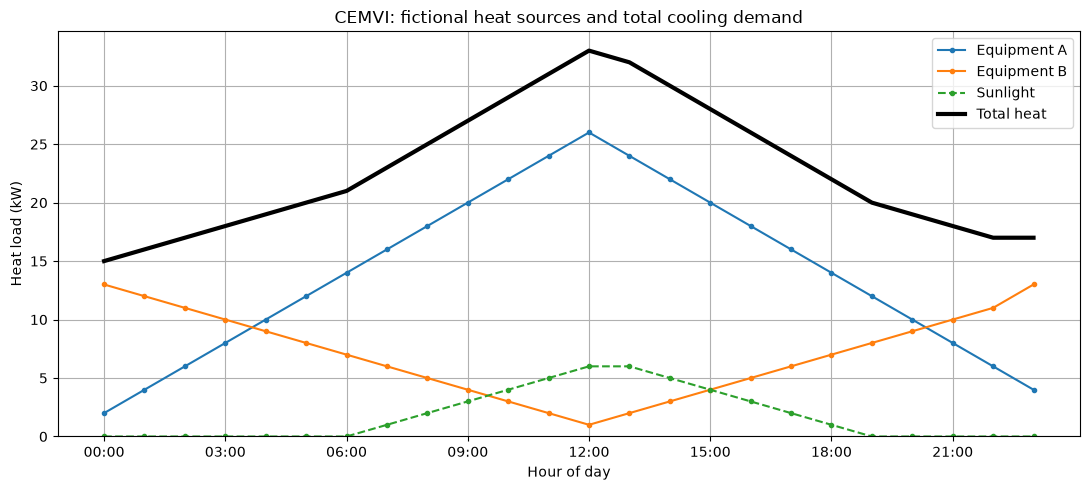

Graph saved: 02_heat_sources.png


In [6]:
import matplotlib.pyplot as plt

a_kw = [int(row["equipment_a_kw"]) for row in rows]
b_kw = [int(row["equipment_b_kw"]) for row in rows]
solar_kw = [int(row["solar_kw"]) for row in rows]
total_kw = [int(row["total_kw"]) for row in rows]

x = range(len(hours))
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(x, a_kw, marker="o", markersize=3, label="Equipment A")
ax.plot(x, b_kw, marker="o", markersize=3, label="Equipment B")
ax.plot(x, solar_kw, marker="o", markersize=3, linestyle="--", label="Sunlight")
ax.plot(x, total_kw, color="black", linewidth=3, label="Total heat")

ax.set_xticks(range(0, 24, 3), hours[::3])
ax.set_xlabel("Hour of day")
ax.set_ylabel("Heat load (kW)")
ax.set_title("CEMVI: fictional heat sources and total cooling demand")
ax.set_ylim(bottom=0)
ax.grid(True)
ax.legend()
fig.tight_layout()

graph_path = csv_path.resolve().parent.parent / "figures" / "02_heat_sources.png"
graph_path.parent.mkdir(exist_ok=True)
fig.savefig(graph_path, dpi=150)

plt.show()
print("Graph saved:", graph_path.name)

At 12:00, Equipment A adds 26 kW, Equipment B adds 1 kW, and sunlight adds 6 kW. Together they make the 33 kW peak. At night, sunlight adds no heat, but the equipment still does.

## Method and limits

### Method
This is a fully fictional 24-hour equipment-room case. For each hour, I added the heat from Equipment A, Equipment B, and sunlight to find the cooling load. Each value represents an average over one hour. I checked all 24 sums: the peak is 33 kW at 12:00, and the total heat to remove over the day is 547 kWh thermal.

At the peak, I assumed chilled water enters the AHU coil at 7°C and returns at 12°C. Using an approximate water heat capacity of 4.19 kJ/(kg·K), the calculated water flow is 1.58 kg/s. The heat-balance equation comes from the [DOE handbook](https://www.energy.gov/documents/doe-hdbk-1012-92vol2), and the approximate water property is recorded from [NIST](https://doi.org/10.6028/NIST.IR.6191).

### Limits
The hourly heat inputs and water tempqeratures are invented, not measurements from a real building or workplace. This simple calculation assumes the cooling system removes each hour's heat during that hour. It does not yet model room heat storage, humidity, ventilation, pipe and pump heat gains, or the detailed performance of the coil and chiller. The 547 kWh is heat removed, not electricity consumed.

## Understanding COP
COP compares the heat a chiller removes with the electrical power its unit uses. In an invented example with COP = 3.0, removing 33 kW of heat at noon requires 33 ÷ 3 = 11 kW of chiller electrical power. If that rate lasts one hour, it uses 11 kWh of electricity. The COP of 3.0 is a teaching assumption, not a measured rating for a real chiller. We will decide how to account for the separate AHU fan and chilled-water pump much later.

In [7]:
example_cop = 3.0  # Invented teaching example
noon_cooling_kw = heat_kw[hours.index("12:00")]
example_chiller_kw = noon_cooling_kw / example_cop

print(f"Noon heat to remove: {noon_cooling_kw} kW thermal")
print(f"Example chiller power: {example_chiller_kw:.1f} kW electric")
print(f"Electricity from 12:00 to 13:00: {example_chiller_kw:.1f} kWh electric")

Noon heat to remove: 33 kW thermal
Example chiller power: 11.0 kW electric
Electricity from 12:00 to 13:00: 11.0 kWh electric


Baseline chiller electricity

I assume a constant baseline COP of 3.0 for this fictional case. For each hour, I divide the cooling load in kW thermal by 3.0 to estimate chiller power in kW electric. Each row represents one hour, so multiplying that power by 1 hour gives electricity in kWh. COP 3.0 is an invented modelling assumption, not a measured chiller rating.

In [8]:
baseline_cop = 3.0       # Invented baseline assumption
hour_duration_h = 1.0    # Each CSV row covers one hour

baseline_power_kw = [
    cooling_kw / baseline_cop
    for cooling_kw in heat_kw
]

baseline_energy_kwh = [
    power_kw * hour_duration_h
    for power_kw in baseline_power_kw
]

print("Hour  | Heat (kW thermal) | Chiller (kW electric) | Electricity (kWh)")
for hour, heat, power, energy in zip(
    hours, heat_kw, baseline_power_kw, baseline_energy_kwh
):
    print(f"{hour} | {heat:>4}              | {power:>6.2f}               | {energy:>6.2f}")

print(f"\nDaily heat removed: {sum(heat_kw):.0f} kWh thermal")
print(f"Daily chiller electricity: {sum(baseline_energy_kwh):.2f} kWh electric")
print(f"Peak chiller power: {max(baseline_power_kw):.2f} kW electric")

Hour  | Heat (kW thermal) | Chiller (kW electric) | Electricity (kWh)
00:00 |   15              |   5.00               |   5.00
01:00 |   16              |   5.33               |   5.33
02:00 |   17              |   5.67               |   5.67
03:00 |   18              |   6.00               |   6.00
04:00 |   19              |   6.33               |   6.33
05:00 |   20              |   6.67               |   6.67
06:00 |   21              |   7.00               |   7.00
07:00 |   23              |   7.67               |   7.67
08:00 |   25              |   8.33               |   8.33
09:00 |   27              |   9.00               |   9.00
10:00 |   29              |   9.67               |   9.67
11:00 |   31              |  10.33               |  10.33
12:00 |   33              |  11.00               |  11.00
13:00 |   32              |  10.67               |  10.67
14:00 |   30              |  10.00               |  10.00
15:00 |   28              |   9.33               |   9.33
16

Electricity boundary

My cooling-system electricity includes the air-cooled chiller unit, the separate AHU fan, and the separate chilled-water pump. I treat the outdoor condenser fan as part of the chiller unit, so I do not count it twice. For this invented 24-hour case, I assume the AHU fan uses 1.2 kW and the water pump uses 0.6 kW continuously. These are illustrative inputs, not measured equipment values. Electricity used by Equipment A and B is outside this cooling-system electricity boundary.

In [9]:
ahu_fan_kw = 1.2       # Invented, runs throughout the 24 hours
water_pump_kw = 0.6    # Invented, runs throughout the 24 hours

system_power_kw = [
    chiller_kw + ahu_fan_kw + water_pump_kw
    for chiller_kw in baseline_power_kw
]

chiller_day_kwh = sum(baseline_energy_kwh)
fan_day_kwh = ahu_fan_kw * len(hours) * hour_duration_h
pump_day_kwh = water_pump_kw * len(hours) * hour_duration_h
system_day_kwh = chiller_day_kwh + fan_day_kwh + pump_day_kwh

noon = hours.index("12:00")

print(f"Chiller: {chiller_day_kwh:.2f} kWh electric")
print(f"AHU fan: {fan_day_kwh:.2f} kWh electric")
print(f"Water pump: {pump_day_kwh:.2f} kWh electric")
print(f"Whole cooling system: {system_day_kwh:.2f} kWh electric")
print(f"Whole-system power at 12:00: {system_power_kw[noon]:.2f} kW electric")

Chiller: 182.33 kWh electric
AHU fan: 28.80 kWh electric
Water pump: 14.40 kWh electric
Whole cooling system: 225.53 kWh electric
Whole-system power at 12:00: 12.80 kW electric


Improved-efficiency scenario

I compare the baseline chiller COP of 3.0 with an illustrative improved COP of 4.0. Both scenarios remove the same fictional hourly cooling loads. The AHU fan remains at 1.2 kW and the chilled-water pump at 0.6 kW for all 24 hours. COP 4.0 is an invented “what if” value, not a measured result or a promise that an equipment change will achieve it.

In [10]:
improved_cop = 4.0  # Invented "what if" assumption

improved_power_kw = [
    cooling_kw / improved_cop
    for cooling_kw in heat_kw
]

improved_energy_kwh = [
    power_kw * hour_duration_h
    for power_kw in improved_power_kw
]

improved_system_power_kw = [
    chiller_kw + ahu_fan_kw + water_pump_kw
    for chiller_kw in improved_power_kw
]

improved_system_energy_kwh = [
    power_kw * hour_duration_h
    for power_kw in improved_system_power_kw
]

noon = hours.index("12:00")

print(f"Cooling demand, unchanged: {sum(heat_kw):.0f} kWh thermal")
print(f"Improved chiller electricity: {sum(improved_energy_kwh):.2f} kWh electric")
print(f"Improved whole-system electricity: {sum(improved_system_energy_kwh):.2f} kWh electric")
print(f"Improved whole-system power at noon: {improved_system_power_kw[noon]:.2f} kW electric")

Cooling demand, unchanged: 547 kWh thermal
Improved chiller electricity: 136.75 kWh electric
Improved whole-system electricity: 179.95 kWh electric
Improved whole-system power at noon: 10.05 kW electric


Baseline system: 225.53 kWh electric/day
Improved system: 179.95 kWh electric/day
Difference: 45.58 kWh electric/day
Relative difference: 20.21%


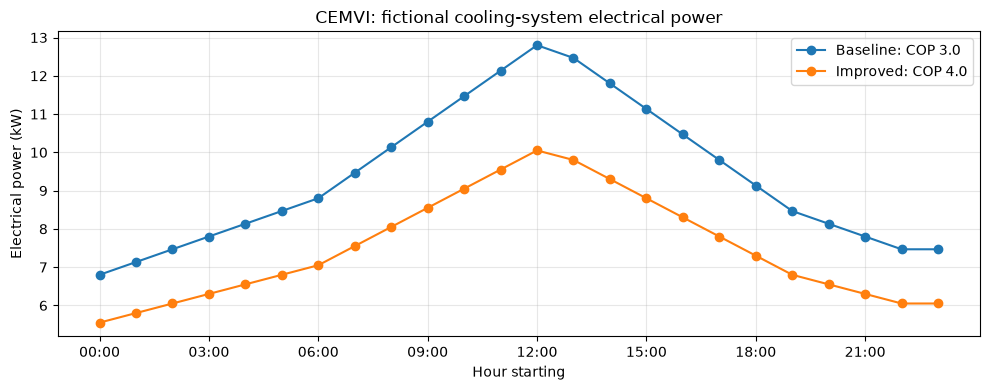

Graph saved: 03_electric_power_comparison.png


In [11]:
import matplotlib.pyplot as plt

baseline_daily_kwh = sum(
    power * hour_duration_h for power in system_power_kw
)
improved_daily_kwh = sum(improved_system_energy_kwh)

difference_kwh = baseline_daily_kwh - improved_daily_kwh
difference_percent = 100 * difference_kwh / baseline_daily_kwh

print(f"Baseline system: {baseline_daily_kwh:.2f} kWh electric/day")
print(f"Improved system: {improved_daily_kwh:.2f} kWh electric/day")
print(f"Difference: {difference_kwh:.2f} kWh electric/day")
print(f"Relative difference: {difference_percent:.2f}%")

x = list(range(len(hours)))
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(x, system_power_kw, marker="o", label="Baseline: COP 3.0")
ax.plot(x, improved_system_power_kw, marker="o", label="Improved: COP 4.0")

ax.set_title("CEMVI: fictional cooling-system electrical power")
ax.set_xlabel("Hour starting")
ax.set_ylabel("Electrical power (kW)")
ax.set_xticks(x[::3])
ax.set_xticklabels(hours[::3])
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()

graph_path = (
    csv_path.resolve().parent.parent
    / "figures"
    / "03_electric_power_comparison.png"
)
graph_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(graph_path, dpi=150)

plt.show()
print("Graph saved:", graph_path.name)

The fictional improved scenario uses 45.58 kWh less cooling-system electricity over this 24-hour day, a 20.21% difference from the baseline. The cooling demand is identical in both scenarios. The graph shows power in kW at each hour; the daily totals show energy in kWh. These results follow from the assumed COP values and are not measured savings.

Interpretation and limitations

Both scenarios remove the same invented 547 kWh of heat during the day. I changed only the assumed chiller COP, from 3.0 to 4.0. The AHU fan and chilled-water pump use the same electricity in both scenarios. The calculated cooling-system electricity falls from 225.53 to 179.95 kWh, a difference of 45.58 kWh (20.21%) for this fictional day.
This difference is a model result, not a measured saving. It does not show that a real chiller or upgrade will achieve COP 4.0. The hourly heat loads and COP values are invented. The model also holds COP, fan power, and pump power constant; it does not account for changing outdoor temperature, part-load performance, fan heat added to the room, or water-loop heat gains. A real prediction would need equipment performance information and operating data.

Fictional solar PV supply

I have invented a 24-hour solar PV electricity profile for one illustrative day. Each value is average electrical power during the hour shown. Output is zero at night, rises in the morning, and reaches an assumed peak of 18 kW around midday. These values are not weather measurements or the predicted output of a selected solar installation. I will compare them with the baseline whole-cooling-system electricity demand while keeping that demand unchanged.

In [12]:
import csv

# Invented solar PV electrical power for 00:00 through 23:00
pv_supply_kw = [
    0, 0, 0, 0, 0, 0, 0,       # 00:00–06:00
    0.5, 2, 5, 10, 15, 18,   # 07:00–12:00
    18, 15, 10, 5, 2, 0.5,   # 13:00–18:00
    0, 0, 0, 0, 0            # 19:00–23:00
]

assert len(hours) == len(pv_supply_kw) == 24
assert all(power >= 0 for power in pv_supply_kw)

pv_csv_path = csv_path.resolve().parent / "pv_supply.csv"

with pv_csv_path.open("w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow(["hour", "pv_kw"])
    writer.writerows(zip(hours, pv_supply_kw))

print("Hours:", len(pv_supply_kw))
print("Peak fictional PV power:", max(pv_supply_kw), "kW electric")
print(
    "Daily fictional PV production:",
    sum(pv_supply_kw) * hour_duration_h,
    "kWh electric"
)
print("Saved:", pv_csv_path.name)

Hours: 24
Peak fictional PV power: 18 kW electric
Daily fictional PV production: 101.0 kWh electric
Saved: pv_supply.csv


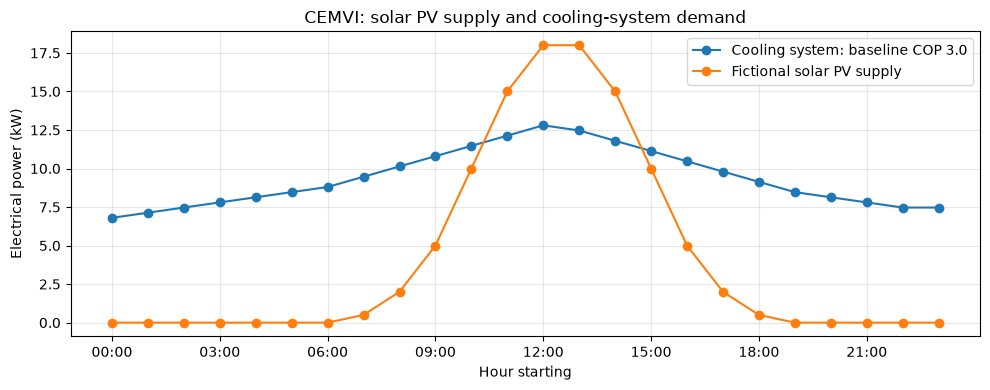

Graph saved: 04_pv_vs_cooling_power.png


In [13]:
import matplotlib.pyplot as plt

assert len(hours) == len(pv_supply_kw) == len(system_power_kw) == 24

x = list(range(24))
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    x, system_power_kw,
    marker="o",
    label="Cooling system: baseline COP 3.0"
)
ax.plot(
    x, pv_supply_kw,
    marker="o",
    label="Fictional solar PV supply"
)

ax.set_title("CEMVI: solar PV supply and cooling-system demand")
ax.set_xlabel("Hour starting")
ax.set_ylabel("Electrical power (kW)")
ax.set_xticks(x[::3])
ax.set_xticklabels(hours[::3])
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()

graph_path = (
    csv_path.resolve().parent.parent
    / "figures"
    / "04_pv_vs_cooling_power.png"
)
graph_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(graph_path, dpi=150)

plt.show()
print("Graph saved:", graph_path.name)

At night, the fictional solar panels provide no electricity while the cooling system still needs power. Around midday, solar output rises above cooling-system demand. The PV profile produces 101 kWh over the day, while baseline cooling-system demand is 225.53 kWh. Comparing these daily totals alone does not tell us how much solar electricity can be used: supply and demand must meet during the same hour.

In [14]:
solar_used_kw = []
grid_remaining_kw = []
unused_pv_kw = []

for demand_kw, pv_kw in zip(system_power_kw, pv_supply_kw):
    used_kw = min(demand_kw, pv_kw)
    solar_used_kw.append(used_kw)
    grid_remaining_kw.append(demand_kw - used_kw)
    unused_pv_kw.append(pv_kw - used_kw)

print("Hour  | Demand | PV    | Solar used | Grid  | Unused PV")
for hour, demand, pv, used, grid, unused in zip(
    hours, system_power_kw, pv_supply_kw,
    solar_used_kw, grid_remaining_kw, unused_pv_kw
):
    print(
        f"{hour} | {demand:6.2f} | {pv:5.2f} | "
        f"{used:10.2f} | {grid:5.2f} | {unused:9.2f}"
    )

print("\nDAILY ENERGY")
print(f"Cooling-system demand: {sum(system_power_kw) * hour_duration_h:.2f} kWh")
print(f"PV produced: {sum(pv_supply_kw) * hour_duration_h:.2f} kWh")
print(f"PV used directly: {sum(solar_used_kw) * hour_duration_h:.2f} kWh")
print(f"Grid supplied: {sum(grid_remaining_kw) * hour_duration_h:.2f} kWh")
print(f"PV unused: {sum(unused_pv_kw) * hour_duration_h:.2f} kWh")

Hour  | Demand | PV    | Solar used | Grid  | Unused PV
00:00 |   6.80 |  0.00 |       0.00 |  6.80 |      0.00
01:00 |   7.13 |  0.00 |       0.00 |  7.13 |      0.00
02:00 |   7.47 |  0.00 |       0.00 |  7.47 |      0.00
03:00 |   7.80 |  0.00 |       0.00 |  7.80 |      0.00
04:00 |   8.13 |  0.00 |       0.00 |  8.13 |      0.00
05:00 |   8.47 |  0.00 |       0.00 |  8.47 |      0.00
06:00 |   8.80 |  0.00 |       0.00 |  8.80 |      0.00
07:00 |   9.47 |  0.50 |       0.50 |  8.97 |      0.00
08:00 |  10.13 |  2.00 |       2.00 |  8.13 |      0.00
09:00 |  10.80 |  5.00 |       5.00 |  5.80 |      0.00
10:00 |  11.47 | 10.00 |      10.00 |  1.47 |      0.00
11:00 |  12.13 | 15.00 |      12.13 |  0.00 |      2.87
12:00 |  12.80 | 18.00 |      12.80 |  0.00 |      5.20
13:00 |  12.47 | 18.00 |      12.47 |  0.00 |      5.53
14:00 |  11.80 | 15.00 |      11.80 |  0.00 |      3.20
15:00 |  11.13 | 10.00 |      10.00 |  1.13 |      0.00
16:00 |  10.47 |  5.00 |       5.00 |  5.47 |   

In [15]:
print(f"Cooling-system demand: {sum(system_power_kw) * hour_duration_h:.2f} kWh")
print(f"Solar used + grid: {(sum(solar_used_kw) + sum(grid_remaining_kw)) * hour_duration_h:.2f} kWh")

Cooling-system demand: 225.53 kWh
Solar used + grid: 225.53 kWh


Solar-first electricity balance

During each one-hour interval, I use available fictional PV electricity to meet cooling-system demand first. The grid supplies any shortfall. PV above demand is labelled unused because this case has no battery or export. Across the day, 84.20 kWh of PV is used directly, 141.33 kWh comes from the grid, and 16.80 kWh of PV is unused. These are calculated results for invented profiles.

Fictional battery

I assume a battery that can hold 12 kWh of stored energy and starts empty. In each hour, PV serves the cooling system first. Extra PV charges the battery until it is full. When PV is insufficient, the battery supplies what it can, then the grid supplies the rest. Charging and discharging are each assumed 90% efficient. The battery does not charge from the grid, and unused PV is not exported. These are invented assumptions; battery charging and discharging power limits are omitted.

In [16]:
battery_capacity_kwh = 12.0
charge_efficiency = 0.90
discharge_efficiency = 0.90
soc_kwh = 0.0  # Energy currently stored; battery starts empty

pv_to_battery_kwh = []
battery_to_load_kwh = []
grid_with_battery_kwh = []
unused_pv_with_battery_kwh = []
soc_history_kwh = []

for demand_kw, pv_kw in zip(system_power_kw, pv_supply_kw):
    demand_kwh = demand_kw * hour_duration_h
    pv_kwh = pv_kw * hour_duration_h

    direct_solar_kwh = min(demand_kwh, pv_kwh)
    surplus_kwh = pv_kwh - direct_solar_kwh
    shortage_kwh = demand_kwh - direct_solar_kwh

    # Put surplus PV into available battery space
    space_kwh = max(0.0, battery_capacity_kwh - soc_kwh)
    charge_kwh = min(surplus_kwh, space_kwh / charge_efficiency)
    soc_kwh += charge_kwh * charge_efficiency

    # Use stored energy when PV cannot meet demand
    delivered_kwh = min(shortage_kwh, soc_kwh * discharge_efficiency)
    soc_kwh = max(0.0, soc_kwh - delivered_kwh / discharge_efficiency)

    grid_kwh = shortage_kwh - delivered_kwh
    unused_kwh = surplus_kwh - charge_kwh

    pv_to_battery_kwh.append(charge_kwh)
    battery_to_load_kwh.append(delivered_kwh)
    grid_with_battery_kwh.append(grid_kwh)
    unused_pv_with_battery_kwh.append(unused_kwh)
    soc_history_kwh.append(soc_kwh)

print(f"PV sent into battery: {sum(pv_to_battery_kwh):.2f} kWh")
print(f"Battery delivered to cooling system: {sum(battery_to_load_kwh):.2f} kWh")
print(f"Grid without battery: {sum(grid_remaining_kw) * hour_duration_h:.2f} kWh")
print(f"Grid with battery: {sum(grid_with_battery_kwh):.2f} kWh")
print(f"Unused PV with battery: {sum(unused_pv_with_battery_kwh):.2f} kWh")
print(f"Battery energy at end of day: {soc_kwh:.2f} kWh")

PV sent into battery: 13.33 kWh
Battery delivered to cooling system: 10.80 kWh
Grid without battery: 141.33 kWh
Grid with battery: 130.53 kWh
Unused PV with battery: 3.47 kWh
Battery energy at end of day: 0.00 kWh


In [17]:
demand_hourly_kwh = [
    power * hour_duration_h for power in system_power_kw
]
pv_hourly_kwh = [
    power * hour_duration_h for power in pv_supply_kw
]
direct_pv_hourly_kwh = [
    power * hour_duration_h for power in solar_used_kw
]

tolerance = 1e-8

for i in range(len(hours)):
    demand_supplied = (
        direct_pv_hourly_kwh[i]
        + battery_to_load_kwh[i]
        + grid_with_battery_kwh[i]
    )
    pv_accounted_for = (
        direct_pv_hourly_kwh[i]
        + pv_to_battery_kwh[i]
        + unused_pv_with_battery_kwh[i]
    )

    assert abs(demand_hourly_kwh[i] - demand_supplied) < tolerance, hours[i]
    assert abs(pv_hourly_kwh[i] - pv_accounted_for) < tolerance, hours[i]
    assert 0 <= soc_history_kwh[i] <= battery_capacity_kwh + tolerance

print(f"All {len(hours)} hourly energy balances passed.")
print(
    f"Demand: {sum(demand_hourly_kwh):.2f} = "
    f"direct PV {sum(direct_pv_hourly_kwh):.2f} + "
    f"battery {sum(battery_to_load_kwh):.2f} + "
    f"grid {sum(grid_with_battery_kwh):.2f} kWh"
)
print(
    f"PV: {sum(pv_hourly_kwh):.2f} = "
    f"direct use {sum(direct_pv_hourly_kwh):.2f} + "
    f"battery charging {sum(pv_to_battery_kwh):.2f} + "
    f"unused {sum(unused_pv_with_battery_kwh):.2f} kWh"
)

All 24 hourly energy balances passed.
Demand: 225.53 = direct PV 84.20 + battery 10.80 + grid 130.53 kWh
PV: 101.00 = direct use 84.20 + battery charging 13.33 + unused 3.47 kWh


Hand checks

12:00–13:00: The cooling system needs 12.80 kWh and PV produces 18.00 kWh. PV supplies 12.80 kWh directly; the remaining 5.20 kWh goes into battery charging. At 90% charging efficiency, this adds 4.68 kWh to the battery. Its stored energy rises from 2.58 to 7.26 kWh. The grid supplies 0 kWh.  
17:00–18:00: The cooling system needs 9.80 kWh and PV supplies 2.00 kWh directly. The battery delivers 4.20 kWh and the grid supplies the remaining 3.60 kWh. Thus, 2.00 + 4.20 + 3.60 = 9.80 kWh. The battery finishes this hour empty.

Case               Grid     Direct PV   Battery    Total (kWh)
Grid only           225.53      0.00      0.00    225.53
PV, no battery      141.33     84.20      0.00    225.53
PV + battery        130.53     84.20     10.80    225.53


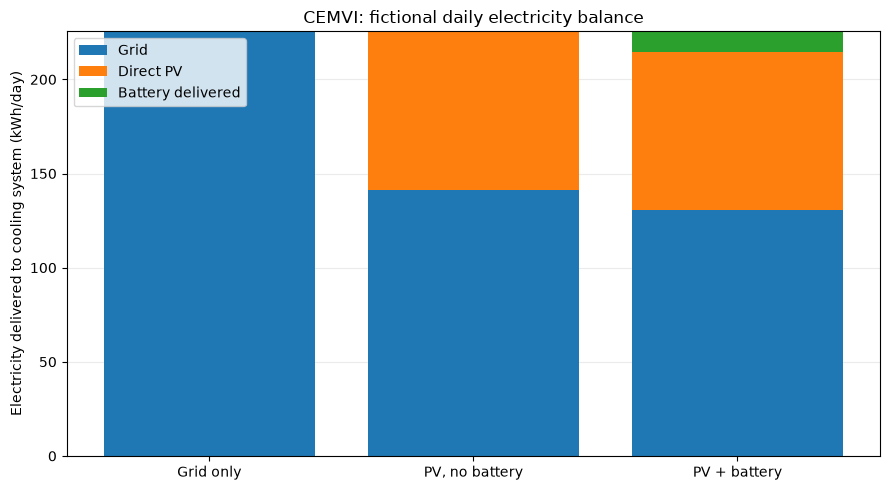

Graph saved: 05_daily_energy_balance.png


In [18]:
import matplotlib.pyplot as plt

daily_demand_kwh = sum(system_power_kw) * hour_duration_h
direct_pv_day_kwh = sum(solar_used_kw) * hour_duration_h
battery_delivered_day_kwh = sum(battery_to_load_kwh)

case_names = ["Grid only", "PV, no battery", "PV + battery"]
grid_values = [
    daily_demand_kwh,
    sum(grid_remaining_kw) * hour_duration_h,
    sum(grid_with_battery_kwh)
]
direct_pv_values = [0, direct_pv_day_kwh, direct_pv_day_kwh]
battery_values = [0, 0, battery_delivered_day_kwh]

print("Case               Grid     Direct PV   Battery    Total (kWh)")
for name, grid, direct, battery in zip(
    case_names, grid_values, direct_pv_values, battery_values
):
    print(
        f"{name:<18} {grid:7.2f}   {direct:7.2f}   "
        f"{battery:7.2f}   {grid + direct + battery:7.2f}"
    )

assert all(
    abs(grid + direct + battery - daily_demand_kwh) < 1e-8
    for grid, direct, battery in zip(
        grid_values, direct_pv_values, battery_values
    )
)

x = list(range(3))
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(x, grid_values, label="Grid")
ax.bar(x, direct_pv_values, bottom=grid_values, label="Direct PV")
ax.bar(
    x,
    battery_values,
    bottom=[g + p for g, p in zip(grid_values, direct_pv_values)],
    label="Battery delivered"
)

ax.set_xticks(x)
ax.set_xticklabels(case_names)
ax.set_ylabel("Electricity delivered to cooling system (kWh/day)")
ax.set_title("CEMVI: fictional daily electricity balance")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.legend()

fig.tight_layout()

graph_path = (
    csv_path.resolve().parent.parent
    / "figures"
    / "05_daily_energy_balance.png"
)
graph_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(graph_path, dpi=150)

plt.show()
print("Graph saved:", graph_path.name)

Three-case comparison Graph

All three fictional cases supply the same 225.53 kWh of cooling-system electricity over one day. The grid-only case takes all 225.53 kWh from the grid. With PV and no battery, direct PV supplies 84.20 kWh and the grid supplies 141.33 kWh; 16.80 kWh of PV is unused. With the invented battery, direct PV still supplies 84.20 kWh, the battery delivers 10.80 kWh, and the grid supplies 130.53 kWh; unused PV falls to 3.47 kWh. The battery receives 13.33 kWh of PV but delivers 10.80 kWh because of the assumed charging and discharging losses. Compared with grid only, the PV-and-battery case reduces calculated grid use by 95.00 kWh (42.12%) for this invented day. These figures are model results, not measured savings.